# 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

sns.set_style("whitegrid")


# 2. Load Dataset

In [2]:
import pandas as pd

df = pd.read_csv("/kaggle/input/student-performance-1-million/student_performance.csv")

print("Dataset loaded successfully")
df.head()


Dataset loaded successfully


,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score,grade
0,1,18.5,95.6,3.8,97.9,A
1,2,14.0,80.0,2.5,83.9,B
2,3,19.5,86.3,5.3,100.0,A
3,4,25.7,70.2,7.0,100.0,A
4,5,13.4,81.9,6.9,92.0,A


# 3. Basic Data Understanding

In [3]:
print("\nData Info:\n")
df.info()


print("\nMissing Values:\n")
print(df.isnull().sum())


print("\nStatistical Summary:\n")
print(df.describe())


Data Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 6 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   student_id               1000000 non-null  int64  
 1   weekly_self_study_hours  1000000 non-null  float64
 2   attendance_percentage    1000000 non-null  float64
 3   class_participation      1000000 non-null  float64
 4   total_score              1000000 non-null  float64
 5   grade                    1000000 non-null  object 
dtypes: float64(4), int64(1), object(1)
memory usage: 45.8+ MB

Missing Values:

student_id                 0
weekly_self_study_hours    0
attendance_percentage      0
class_participation        0
total_score                0
grade                      0
dtype: int64

Statistical Summary:

           student_id  weekly_self_study_hours  attendance_percentage  \
count  1000000.000000           1000000.000000         1000000.0

# 4. Data Cleaning

In [4]:
df = df.drop(columns=["student_id"], errors="ignore")


df = df.drop(columns=["total_score"], errors="ignore")


print("\nColumns after cleaning:\n", df.columns)


Columns after cleaning:
 Index(['weekly_self_study_hours', 'attendance_percentage',
       'class_participation', 'grade'],
      dtype='object')


# 5. Exploratory Data Analysis (EDA)

# 5.1 Grade Distribution

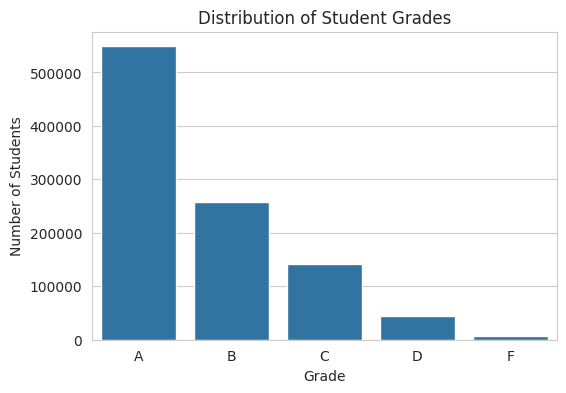

In [5]:
plt.figure(figsize=(6,4))
sns.countplot(x="grade", data=df)
plt.title("Distribution of Student Grades")
plt.xlabel("Grade")
plt.ylabel("Number of Students")
plt.show()

# 5.2 Feature Distributions

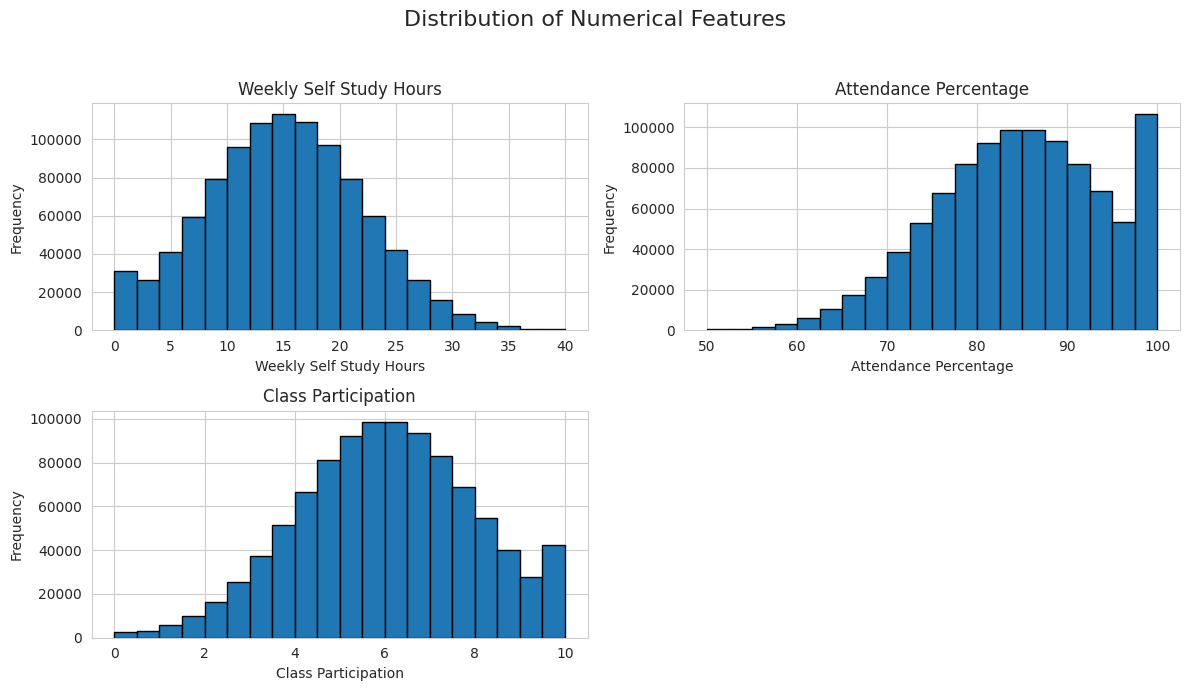

In [6]:
import matplotlib.pyplot as plt

numeric_cols = df.drop(columns=["grade"]).columns

axes = df[numeric_cols].hist(
    figsize=(12, 7),
    bins=20,
    edgecolor="black"
)

# Add labels to each subplot
for ax, col in zip(axes.flatten(), numeric_cols):
    ax.set_title(col.replace("_", " ").title())
    ax.set_xlabel(col.replace("_", " ").title())
    ax.set_ylabel("Frequency")

plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


# 5.3 Boxplots for Outlier Detection

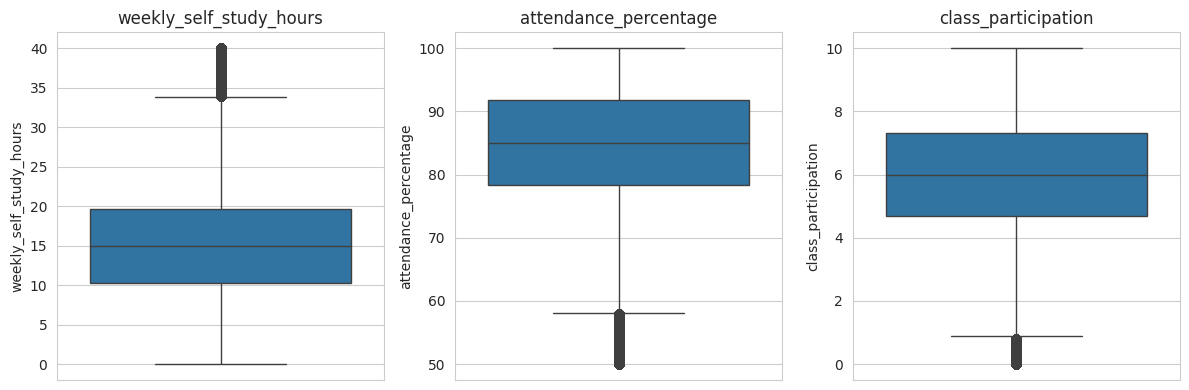

In [7]:
plt.figure(figsize=(12,4))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(1, len(numeric_cols), i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()


# 5.4 Relationship: Study Hours vs Grade

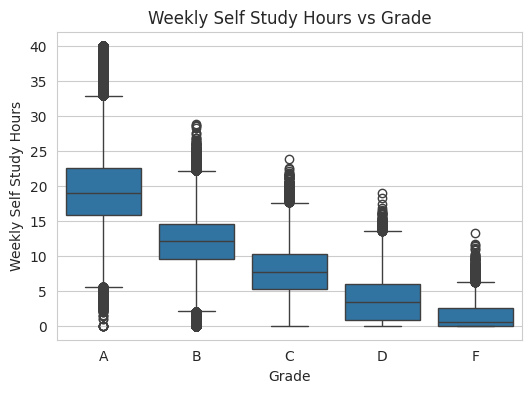

In [8]:
if "weekly_self_study_hours" in df.columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x="grade", y="weekly_self_study_hours", data=df)
    plt.title("Weekly Self Study Hours vs Grade")
    plt.xlabel("Grade")
    plt.ylabel("Weekly Self Study Hours")
    plt.show()


# 6. Feature Selection & Encoding

In [9]:
X = df.drop("grade", axis=1)
y = df["grade"]


le = LabelEncoder()
y = le.fit_transform(y)

# 7. Train-Test Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
X, y,
test_size=0.2,
random_state=42,
stratify=y)

# 8. Model Building

# 8.1 Logistic Regression (Baseline Model)

In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Logistic Regression
log_reg = LogisticRegression(max_iter=3000)
log_reg.fit(X_train_scaled, y_train)

log_pred = log_reg.predict(X_test_scaled)
log_acc = accuracy_score(y_test, log_pred)
log_f1 = f1_score(y_test, log_pred, average="weighted")

print("Logistic Regression Accuracy:", round(log_acc, 4))
print("Logistic Regression F1 Score:", round(log_f1, 4))

Logistic Regression Accuracy: 0.6958
Logistic Regression F1 Score: 0.6866


# 8.2 Decision Tree

In [12]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

dt_acc = accuracy_score(y_test, dt_pred)
dt_f1 = f1_score(y_test, dt_pred, average="weighted")

print("Decision Tree Accuracy:", round(dt_acc, 4))
print("Decision Tree F1 Score:", round(dt_f1, 4))


Decision Tree Accuracy: 0.6092
Decision Tree F1 Score: 0.6074


# 8.3 Random Forest (Improved Model)

In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score

rf = RandomForestClassifier(
    n_estimators=150,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred, average="weighted")

print("Random Forest Accuracy:", round(rf_acc, 4))
print("Random Forest F1 Score:", round(rf_f1, 4))


Random Forest Accuracy: 0.6451
Random Forest F1 Score: 0.6406


# 8.4 Gradient Boosting

In [14]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score

gb = GradientBoostingClassifier(
    n_estimators=100,      # reduced
    learning_rate=0.1,     # faster convergence
    max_depth=3,           # shallow trees
    random_state=42
)

gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)

gb_acc = accuracy_score(y_test, gb_pred)
gb_f1 = f1_score(y_test, gb_pred, average="weighted")

print("Gradient Boosting Accuracy:", round(gb_acc, 4))
print("Gradient Boosting F1 Score:", round(gb_f1, 4))


Gradient Boosting Accuracy: 0.6955
Gradient Boosting F1 Score: 0.6869


# 8.5 XGBosst

In [15]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softmax",
    num_class=len(set(y)),
    eval_metric="mlogloss",
    random_state=42
)

xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

xgb_acc = accuracy_score(y_test, xgb_pred)
xgb_f1 = f1_score(y_test, xgb_pred, average="weighted")

print("XGBoost Accuracy:", round(xgb_acc, 4))
print("XGBoost F1 Score:", round(xgb_f1, 4))


XGBoost Accuracy: 0.6956
XGBoost F1 Score: 0.687


# 9. Model Evaluation & Comparison

In [16]:
results_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost"
    ],
    "Accuracy": [
        log_acc,
        dt_acc,
        rf_acc,
        gb_acc,
        xgb_acc
    ],
    "F1 Score": [
        log_f1,
        dt_f1,
        rf_f1,
        gb_f1,
        xgb_f1
    ]
})

results_df


,Model,Accuracy,F1 Score
0,Logistic Regression,0.695755,0.686596
1,Decision Tree,0.609160,0.607429
2,Random Forest,0.645095,0.640650
3,Gradient Boosting,0.695525,0.686904
4,XGBoost,0.695550,0.686963


# 10. Confusion Matrix

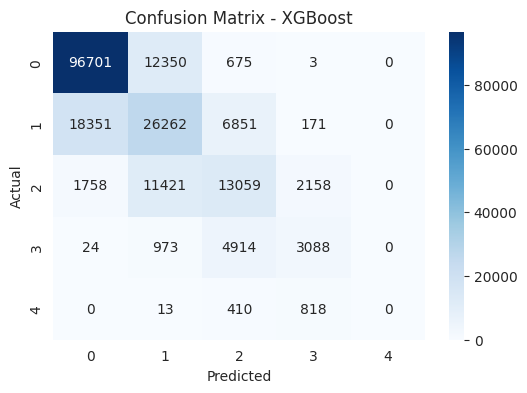

In [17]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, xgb_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# 11. Cross-Validation (Model Stability)

In [18]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    xgb,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Cross-validation scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())


Cross-validation scores: [0.69555 0.69514 0.69519 0.69647 0.69495]
Mean CV Accuracy: 0.69546


# 12. Conclusion

*This project explored student performance prediction using multiple machine learning models, including Logistic Regression, Decision Tree, Random Forest, Gradient Boosting, and XGBoost. Comprehensive exploratory data analysis was performed to understand feature distributions and behavioral patterns. Among all models, Gradient Boosting and XGBoost achieved the best overall performance with balanced accuracy and F1-scores (~69.5%), indicating their superior ability to capture complex relationships in the data. The results demonstrate that student academic outcomes can be reasonably predicted using behavioral and engagement-related features.*

# 13. Insights
* Ensemble models (Gradient Boosting and XGBoost) achieved the best performance, indicating their ability to capture complex patterns in student behavior data.

* Decision Tree showed weaker performance due to overfitting, while Logistic Regression provided a stable baseline.

* Most prediction errors occurred between neighboring grade categories, reflecting realistic academic variability.

* Study habits and academic engagement features played a significant role in predicting student performance.